<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# read dataset
html_df = pd.read_csv("/content/HTML_Top13_Features.csv")


---

In [ ]:
html_df.describe()

,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
count,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,1.999700e+04,19997.000000,19997.000000,19997.000000
mean,884.284093,483.913637,0.371615,5.166407,1.319648,7.261689,0.118302,4.116942,20.723359,55.149622,2.313485e+04,55.626544,742.790119,0.500025
std,3466.036814,984.328387,0.164450,0.387730,2.833063,12.329298,0.076159,2.050831,686.987243,119.753444,8.233276e+04,169.391932,6484.590670,0.500013
min,0.000000,3.000000,0.000000,0.914438,0.000000,0.000000,0.000009,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,47.000000,57.000000,0.286301,4.991718,0.000000,1.000000,0.070555,4.356263,1.000000,1.000000,2.370000e+02,3.000000,11.000000,0.000000
50%,265.000000,182.000000,0.396039,5.179042,1.000000,3.000000,0.108181,5.042327,1.000000,16.000000,2.774000e+03,11.000000,99.000000,1.000000
75%,1037.000000,600.000000,0.487342,5.354134,2.000000,9.000000,0.149205,5.366036,11.000000,66.000000,1.162600e+04,46.000000,422.000000,1.000000
max,283826.000000,43591.000000,0.854354,7.874702,189.000000,333.000000,0.830095,6.274234,77698.000000,5550.000000,2.506028e+06,6190.000000,604256.000000,1.000000


In [ ]:
html_df.shape

(19997, 15)

In [ ]:
print(list(html_df.columns))

['file_name', 'url_punct_char_count', 'tag_count', 'whitespace_ratio', 'entropy', 'form_count', 'embedded_js_count', 'html_whitespace_ratio', 'script_entropy', 'min_link_length', 'external_link_count', 'total_script_characters', 'internal_link_count', 'url_digit_count', 'label']


In [ ]:
html_df.head()

,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
0,sample_09001.html,756,475,0.476933,5.072891,0,11,0.152737,4.906402,1,57,15762,39,109,0
1,sample_09002.html,287,82,0.356557,5.202024,0,3,0.179456,4.625064,21,8,2543,27,130,0
2,sample_09003.html,667,406,0.390225,5.164168,1,10,0.149810,4.220362,9,80,7163,26,333,0
3,sample_09004.html,1204,321,0.534781,5.671159,0,33,0.025707,5.626662,17,74,268250,2,1013,0
4,sample_09005.html,2606,665,0.441595,5.136624,5,8,0.130050,5.462992,8,243,7666,8,924,0


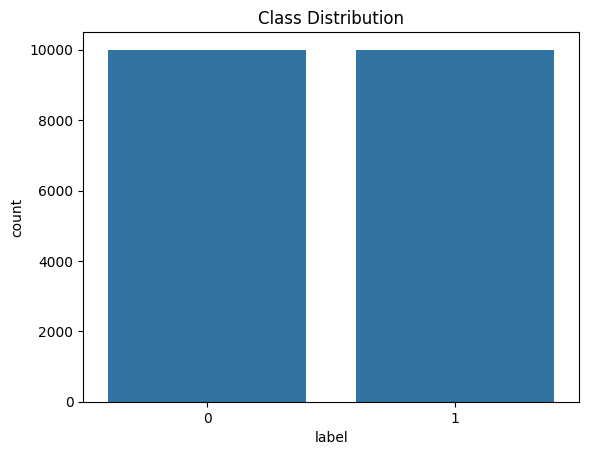

In [ ]:
# verify that the dataset is balanced (50% bengin, 50% malicious)

sns.countplot(data=html_df, x="label")
plt.title("Class Distribution")
plt.show()

In [ ]:
# only 3 samples are missing here
benign_count = (html_df["label"] == 0).sum()
malicious_count = (html_df["label"] == 1).sum()

print("Benign:", benign_count)
print("Malicious:", malicious_count)

Benign: 9998
Malicious: 9999


<Axes: >

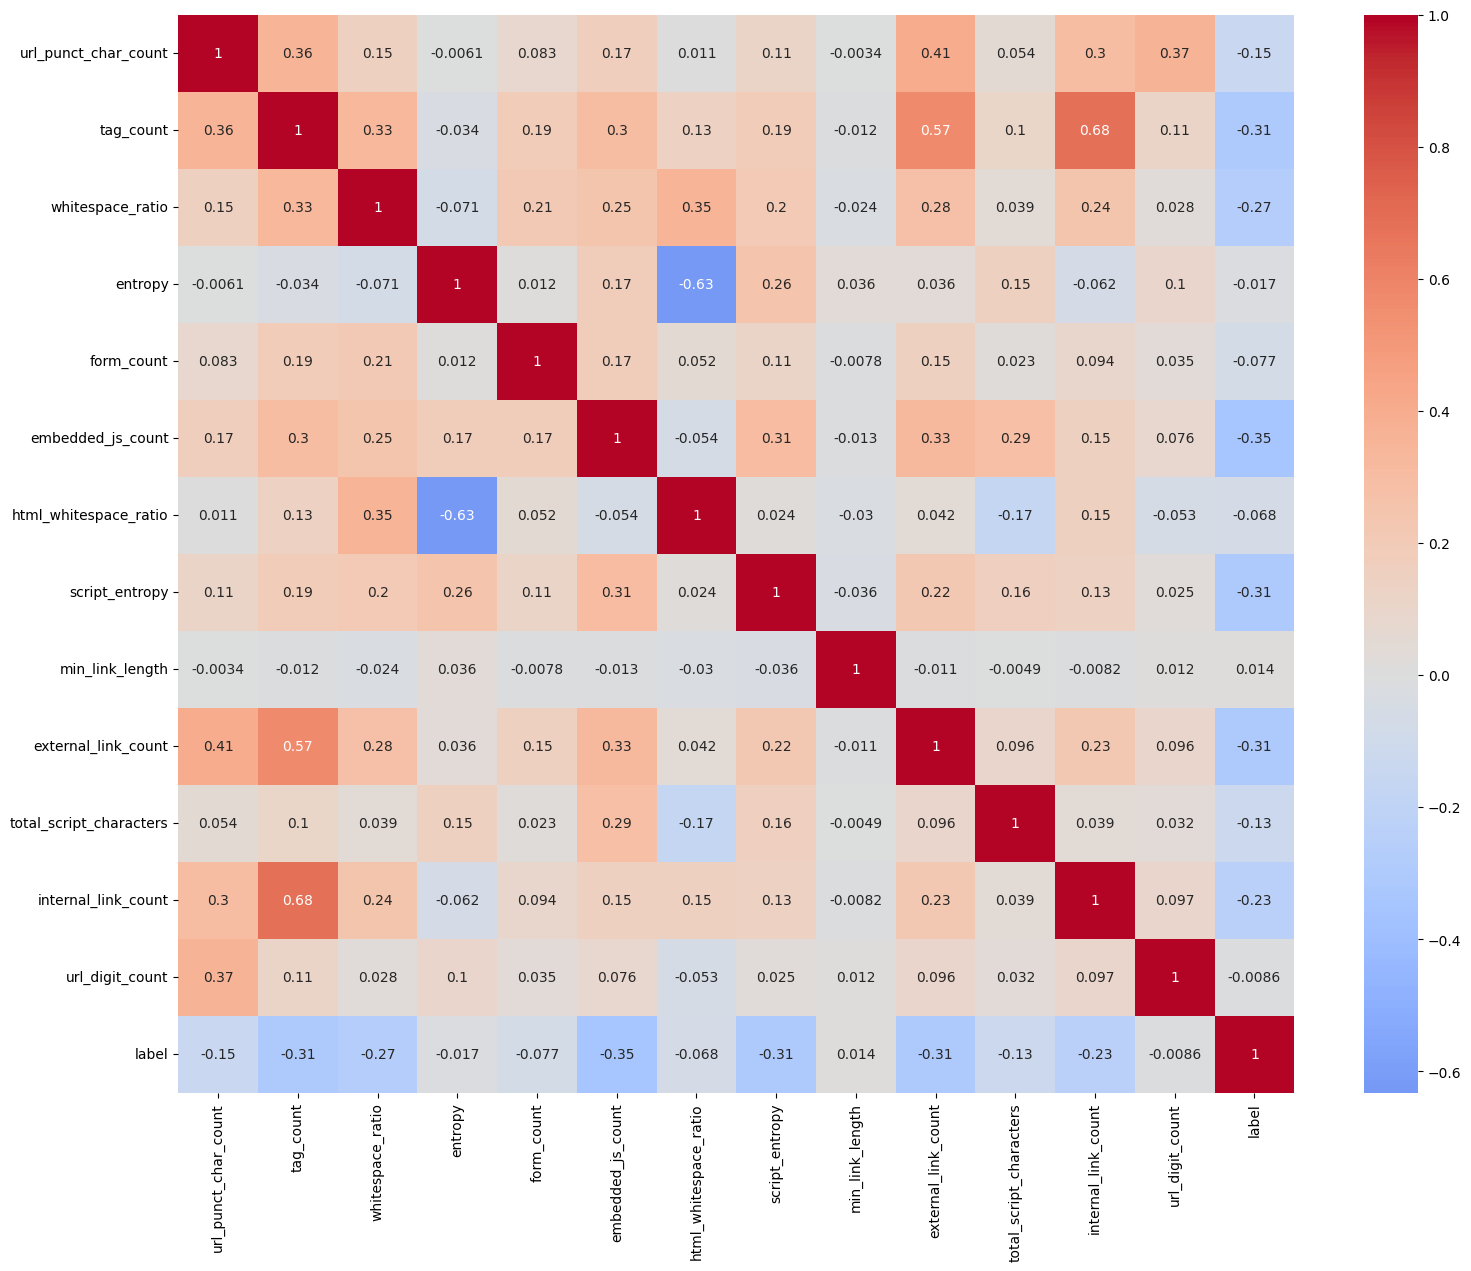

In [ ]:
# Correlation Heatmap (all features)

plt.figure(figsize=(18, 14))
corr = html_df.drop(columns='file_name').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

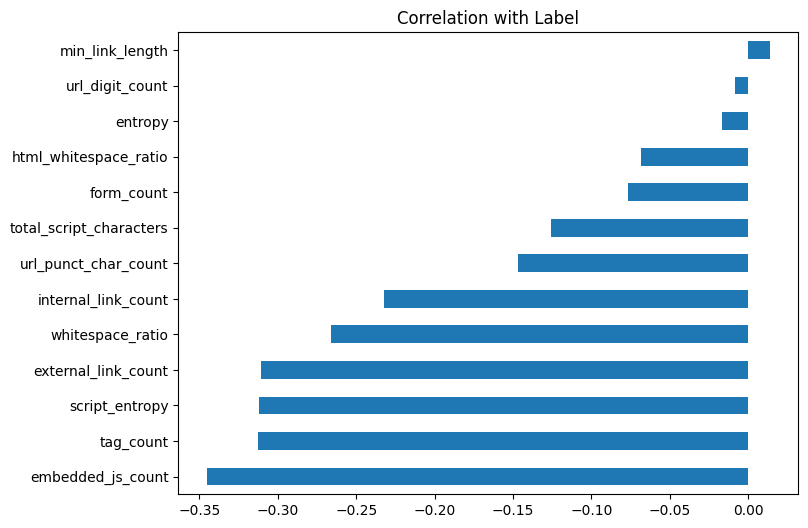

In [ ]:
# Correlation Heatmap for Label

corr = html_df.drop(columns='file_name').corr()["label"].drop('label')

corr.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Label")
plt.show()

# Note:
# (+) correlation → associated with malicious files.
# (-) correlation → associated with benign files.

**HTML Dataset Observations**
- The class distribution is NOT Balanced!
- There's three lost samples! the dataset contains Benign: 9998, Malicious: 9999
- It contains 15 Columns correctly (13 Selected features + file_name col + label col)
- The samples are sorted (bengin first then malicious)

**Reproduce the Baseline**

In [ ]:
X=html_df.drop(columns=['file_name', 'label'])
y=html_df['label']

In [ ]:
hiX_train, X_test, y_train, y_test=train_test_split(X,y,train_size=0.7, random_state=42, stratify=y)

**Decision Tree**

In [ ]:
model_dt=DecisionTreeClassifier(random_state=42)
model_dt.fit(hiX_train, y_train)
y_pred_dt=model_dt.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,y_pred_dt)
precision=precision_score(y_test,y_pred_dt, average='macro')
recall=recall_score(y_test,y_pred_dt, average='macro')
F1=f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1_score: {F1:.4f}")

Accuracy: 0.8955
Precision: 0.8957
Recall: 0.8955
F1_score: 0.8955


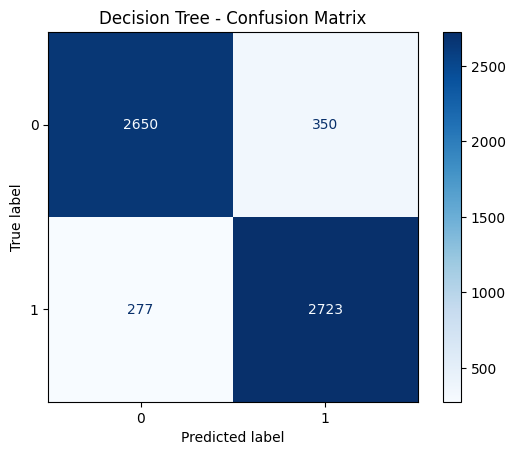

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disply = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disply.plot(cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [ ]:
importances = model_dt.feature_importances_
feat_importance = pd.Series(importances, index=hiX_train.columns).sort_values(ascending=False)
print(feat_importance)


url_punct_char_count       0.374431
whitespace_ratio           0.086367
script_entropy             0.070057
html_whitespace_ratio      0.064439
min_link_length            0.059630
tag_count                  0.052544
entropy                    0.051819
internal_link_count        0.048492
external_link_count        0.045972
form_count                 0.040987
embedded_js_count          0.037267
total_script_characters    0.035857
url_digit_count            0.032137
dtype: float64


**Random Forest**

In [ ]:
model_rf=RandomForestClassifier(random_state=42)
model_rf.fit(hiX_train, y_train)
y_pred_rf=model_rf.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,y_pred_rf)
precision=precision_score(y_test,y_pred_rf, average='macro')
recall=recall_score(y_test,y_pred_rf, average='macro')
F1=f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1_score: {F1:.4f}")


Accuracy: 0.9345
Precision: 0.9346
Recall: 0.9345
F1_score: 0.9345


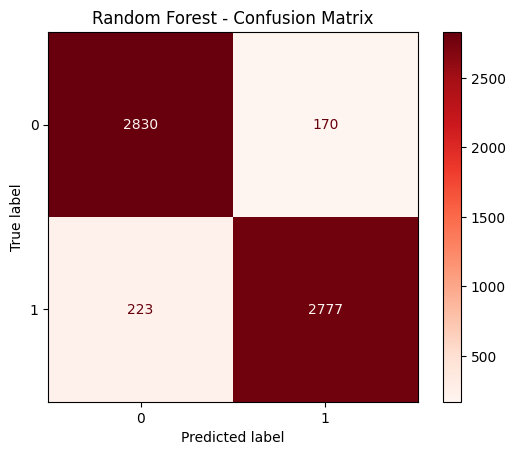

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
display.plot(cmap="Reds")
plt.title("Random Forest - Confusion Matrix")
plt.show()

**XGBoost**

In [ ]:
model_xg=XGBClassifier(random_state=42)
model_xg.fit(hiX_train, y_train)
y_pred_xg=model_xg.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,y_pred_xg)
precision=precision_score(y_test,y_pred_xg, average='macro')
recall=recall_score(y_test,y_pred_xg, average='macro')
F1=f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1_score: {F1:.4f}")

Accuracy: 0.9308
Precision: 0.9308
Recall: 0.9308
F1_score: 0.9308


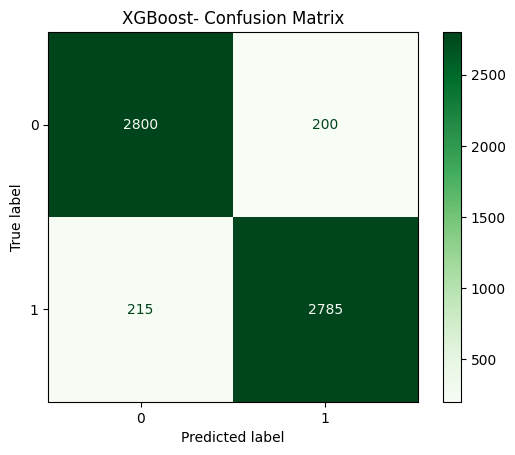

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
display.plot(cmap="Greens")
plt.title("XGBoost- Confusion Matrix")
plt.show()